# EDA - Phan bo train/val/test theo lop du lieu

Notebook nay mo ta tap du lieu goc trong `DataSet/Data`, sau do tach du lieu theo ty le **80/10/10** thanh `train`, `val` va `test`.

Split duoc thuc hien theo tung lop voi seed co dinh de dam bao co the tai lap. Anh duoc copy sang `DataSet/Data_Split_80_10_10`, khong sua truc tiep du lieu goc.


In [1]:
from pathlib import Path
import random
import shutil

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

SOURCE_DIR = Path("DataSet/Data")
SPLIT_DIR = Path("DataSet/Data_Split_80_10_10")

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
RANDOM_SEED = 42
REBUILD_SPLIT_FOLDER = True

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


In [2]:
def list_image_files(class_dir: Path) -> list[Path]:
    return sorted(
        image_path
        for image_path in class_dir.rglob("*")
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS
    )


def split_class_images(
    images: list[Path],
    val_ratio: float = 0.10,
    test_ratio: float = 0.10,
    seed: int = 42,
) -> tuple[list[Path], list[Path], list[Path]]:
    rng = random.Random(seed)
    shuffled_images = images[:]
    rng.shuffle(shuffled_images)

    if len(shuffled_images) >= 3:
        test_count = max(1, round(len(shuffled_images) * test_ratio))
        val_count = max(1, round(len(shuffled_images) * val_ratio))
    elif len(shuffled_images) == 2:
        test_count = 1
        val_count = 0
    else:
        test_count = 0
        val_count = 0

    # Dam bao con it nhat 1 anh train neu lop co du lieu.
    overflow = max(0, test_count + val_count - (len(shuffled_images) - 1))
    if overflow:
        reduce_val = min(val_count, overflow)
        val_count -= reduce_val
        overflow -= reduce_val
        test_count = max(0, test_count - overflow)

    test_images = shuffled_images[:test_count]
    val_images = shuffled_images[test_count:test_count + val_count]
    train_images = shuffled_images[test_count + val_count:]
    return train_images, val_images, test_images


def copy_split_images(split_images: dict[str, list[Path]], class_dir: Path, class_name: str, split_dir: Path) -> None:
    for split_name, images in split_images.items():
        target_class_dir = split_dir / split_name / class_name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for image_path in images:
            relative_path = image_path.relative_to(class_dir)
            target_path = target_class_dir / relative_path
            target_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(image_path, target_path)


def build_train_val_test_split(
    source_dir: Path,
    split_dir: Path,
    val_ratio: float = 0.10,
    test_ratio: float = 0.10,
    seed: int = 42,
    rebuild: bool = True,
) -> list[dict[str, int]]:
    if not source_dir.exists():
        raise FileNotFoundError(f"Khong tim thay thu muc dataset: {source_dir}")

    if rebuild and split_dir.exists():
        shutil.rmtree(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)

    split_rows = []

    for class_dir in sorted(path for path in source_dir.iterdir() if path.is_dir()):
        images = list_image_files(class_dir)
        class_seed = seed + sum(ord(char) for char in class_dir.name)
        train_images, val_images, test_images = split_class_images(
            images,
            val_ratio=val_ratio,
            test_ratio=test_ratio,
            seed=class_seed,
        )

        copy_split_images(
            {
                "train": train_images,
                "val": val_images,
                "test": test_images,
            },
            class_dir=class_dir,
            class_name=class_dir.name,
            split_dir=split_dir,
        )

        split_rows.append(
            {
                "class_name": class_dir.name,
                "total_count": len(images),
                "train_count": len(train_images),
                "val_count": len(val_images),
                "test_count": len(test_images),
            }
        )

    return sorted(split_rows, key=lambda row: row["total_count"], reverse=True)


split_counts = build_train_val_test_split(
    SOURCE_DIR,
    SPLIT_DIR,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=RANDOM_SEED,
    rebuild=REBUILD_SPLIT_FOLDER,
)

split_counts


[{'class_name': 'Paper_Cardboard',
  'total_count': 4078,
  'train_count': 3262,
  'val_count': 408,
  'test_count': 408},
 {'class_name': 'Plastic',
  'total_count': 3585,
  'train_count': 2869,
  'val_count': 358,
  'test_count': 358},
 {'class_name': 'Glass',
  'total_count': 3228,
  'train_count': 2582,
  'val_count': 323,
  'test_count': 323},
 {'class_name': 'Metal',
  'total_count': 3060,
  'train_count': 2448,
  'val_count': 306,
  'test_count': 306},
 {'class_name': 'Biological',
  'total_count': 2820,
  'train_count': 2256,
  'val_count': 282,
  'test_count': 282},
 {'class_name': 'General_Waste',
  'total_count': 1452,
  'train_count': 1162,
  'val_count': 145,
  'test_count': 145},
 {'class_name': 'Battery',
  'total_count': 789,
  'train_count': 631,
  'val_count': 79,
  'test_count': 79}]

**Tong anh:** 19,012 | **Train:** 15,210 (80.00%) | **Val:** 1,901 (10.00%) | **Test:** 1,901 (10.00%)
**Split dir:** `DataSet/Data_Split_80_10_10` | **Seed:** 42 | **Target split:** 80%/10%/10%

| Lop du lieu | Train | Val | Test | Tong | Val (%) | Test (%) |
|---|---:|---:|---:|---:|---:|---:|
| Paper_Cardboard | 3262 | 408 | 408 | 4078 | 10.00 | 10.00 |
| Plastic | 2869 | 358 | 358 | 3585 | 9.99 | 9.99 |
| Glass | 2582 | 323 | 323 | 3228 | 10.01 | 10.01 |
| Metal | 2448 | 306 | 306 | 3060 | 10.00 | 10.00 |
| Biological | 2256 | 282 | 282 | 2820 | 10.00 | 10.00 |
| General_Waste | 1162 | 145 | 145 | 1452 | 9.99 | 9.99 |
| Battery | 631 | 79 | 79 | 789 | 10.01 | 10.01 |

Ghi chu: split duoc lay theo tung lop de `val` va `test` deu giu phan bo gan voi tap goc. Do lam tron theo so anh moi lop, ty le thuc te se xap xi 80/10/10.

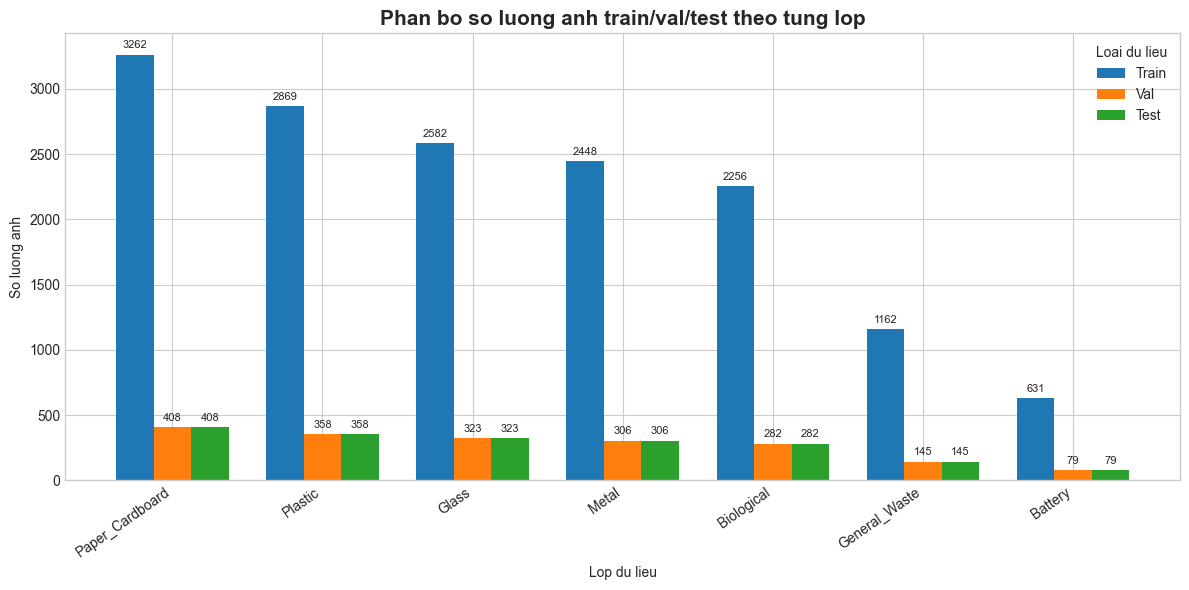

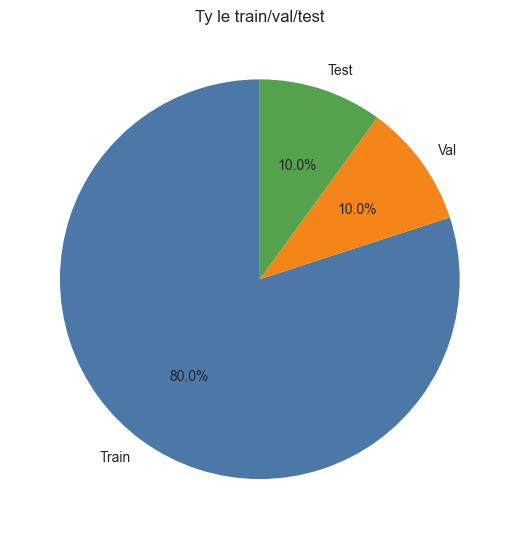

In [3]:
total_train = sum(row["train_count"] for row in split_counts)
total_val = sum(row["val_count"] for row in split_counts)
total_test = sum(row["test_count"] for row in split_counts)
total_images = sum(row["total_count"] for row in split_counts)

train_ratio = total_train / total_images * 100 if total_images else 0
val_ratio = total_val / total_images * 100 if total_images else 0
test_ratio = total_test / total_images * 100 if total_images else 0

table_lines = [
    f"**Tong anh:** {total_images:,} | **Train:** {total_train:,} ({train_ratio:.2f}%) | "
    f"**Val:** {total_val:,} ({val_ratio:.2f}%) | **Test:** {total_test:,} ({test_ratio:.2f}%)",
    f"**Split dir:** `{SPLIT_DIR}` | **Seed:** {RANDOM_SEED} | "
    f"**Target split:** {TRAIN_RATIO:.0%}/{VAL_RATIO:.0%}/{TEST_RATIO:.0%}",
    "",
    "| Lop du lieu | Train | Val | Test | Tong | Val (%) | Test (%) |",
    "|---|---:|---:|---:|---:|---:|---:|",
]

for row in split_counts:
    val_percent = row["val_count"] / row["total_count"] * 100 if row["total_count"] else 0
    test_percent = row["test_count"] / row["total_count"] * 100 if row["total_count"] else 0
    table_lines.append(
        f"| {row['class_name']} | {row['train_count']} | {row['val_count']} | {row['test_count']} | "
        f"{row['total_count']} | {val_percent:.2f} | {test_percent:.2f} |"
    )

table_lines.extend(
    [
        "",
        "Ghi chu: split duoc lay theo tung lop de `val` va `test` deu giu phan bo gan voi tap goc. "
        "Do lam tron theo so anh moi lop, ty le thuc te se xap xi 80/10/10.",
    ]
)

display(Markdown("\n".join(table_lines)))

classes = [row["class_name"] for row in split_counts]
train_values = [row["train_count"] for row in split_counts]
val_values = [row["val_count"] for row in split_counts]
test_values = [row["test_count"] for row in split_counts]
x_positions = list(range(len(classes)))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
train_bars = ax.bar([x - bar_width for x in x_positions], train_values, width=bar_width, label="Train")
val_bars = ax.bar(x_positions, val_values, width=bar_width, label="Val")
test_bars = ax.bar([x + bar_width for x in x_positions], test_values, width=bar_width, label="Test")

ax.set_title("Phan bo so luong anh train/val/test theo tung lop", fontsize=15, fontweight="bold")
ax.set_xlabel("Lop du lieu")
ax.set_ylabel("So luong anh")
ax.set_xticks(x_positions)
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.legend(title="Loai du lieu")
ax.bar_label(train_bars, padding=3, fontsize=8)
ax.bar_label(val_bars, padding=3, fontsize=8)
ax.bar_label(test_bars, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(
    [total_train, total_val, total_test],
    labels=["Train", "Val", "Test"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_title("Ty le train/val/test")
plt.tight_layout()
plt.show()
